In [24]:
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_openai import OpenAIEmbeddings
from langchain.tools import tool
# from langchain_core import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph , START , END
from typing_extensions import Annotated, TypedDict, Literal, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
import os
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain.agents import create_agent 
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun
load_dotenv()

True

In [67]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [26]:
url = ['https://en.wikipedia.org/wiki/AI_agent']

doc = []
loader = WebBaseLoader(url)
data = loader.load()
doc.extend(data)


In [27]:
import re

clear_output = re.sub(r'[^A-Za-z .,!?]\s+', '', doc[0].page_content)
doc[0].page_content = clear_output

In [28]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
split_doc = splitter.split_documents(doc)
vector_store = FAISS.from_documents(split_doc, embeddings)

retriever = vector_store.as_retriever()

In [44]:
@tool("retriever_store")
def retriever_store(query):
    """Use this tool to retrieve information about AI agents from the vector store."""

    print("Retriever Tool Called with query:", query)

    docs = retriever.invoke(query)
    return "\n\n".join([doc.page_content for doc in docs])

In [45]:
@tool("wikipedia_search")
def wikipedia_search(query):
    """Use this tool to get a summary of information from Wikipedia."""
    print("Wikipedia Search Tool Called with query:", query)
    wiki = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(doc_content_chars_max=1000, top_k_results=1))
    return wiki.invoke(query)

In [46]:
# print(wikipedia_search("What is article 370 ? "))

In [68]:
tools = [retriever_store, wikipedia_search]

react_node = create_agent(model=model, tools=tools)

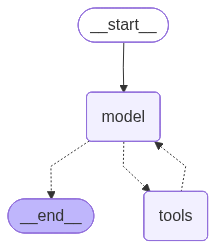

In [61]:
react_node

In [62]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage] , add_messages]

In [69]:
builder = StateGraph(AgentState)

builder.add_node("React_agent_legal", react_node)

builder.add_edge(START, "React_agent_legal")
builder.add_edge("React_agent_legal", END)


workflow = builder.compile()

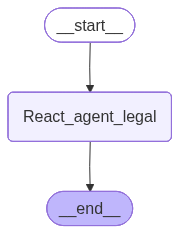

In [70]:
workflow

In [71]:
result = workflow.invoke({"messages": [HumanMessage(content="What do you mean by the article 370? and how supreme court has played a role in it ?")]})

Wikipedia Search Tool Called with query: Article 370 of the Indian Constitution
Wikipedia Search Tool Called with query: Supreme Court of India and Article 370
Wikipedia Search Tool Called with query: Supreme Court of India role in Article 370
Wikipedia Search Tool Called with query: Supreme Court of India Article 370 case


In [72]:
result

{'messages': [HumanMessage(content='What do you mean by the article 370? and how supreme court has played a role in it ?', additional_kwargs={}, response_metadata={}, id='1814614c-cbfe-4aa6-9c2a-13e25219e8d6'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 99, 'total_tokens': 157, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_83e2dd34fc', 'id': 'chatcmpl-DX0P6Jxe2pYKKAp6cISM4GsPJg06G', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019daf12-e903-7e10-b72b-27ed23b8b791-0', tool_calls=[{'name': 'wikipedia_search', 'args': {'query': 'Article 370 of the Indian Constitution'}, 'id': 'call_4kaeASK7c3ZU8um2HSaR1

In [73]:
from IPython.display import Markdown, display

display(Markdown(f"### Answer\n\n{result['messages'][-1].content}"))

### Answer

### Article 370 Overview

Article 370 of the Indian Constitution granted special status to the region of Jammu and Kashmir. This article was part of the Indian Constitution's provisions for temporary, transitional, and special arrangements. It allowed Jammu and Kashmir to have its own constitution, a separate state flag, and significant autonomy over internal matters. 

The article was drafted in Part XXI of the Constitution and stated that the Constituent Assembly of Jammu and Kashmir could recommend the extent to which the Indian Constitution would apply to the state. Importantly, it also allowed for the possibility of abrogation, meaning that the state assembly could decide to revoke Article 370, which would then subject Jammu and Kashmir to the full application of the Indian Constitution.

### Role of the Supreme Court

The Supreme Court of India has played a significant role in the context of Article 370, especially following its abrogation on October 31, 2019. The court has been involved in various legal challenges regarding the constitutionality of the abrogation and the processes followed by the government. 

Legal petitions were filed questioning the validity of the government's actions, arguing that the abrogation was unconstitutional and violated the rights of the people of Jammu and Kashmir. The Supreme Court's decisions in these cases are crucial as they will determine the legal standing of the abrogation and the future of the special status that was once accorded to Jammu and Kashmir.

The Supreme Court's involvement reflects its role as the guardian of the Constitution, ensuring that any changes to constitutional provisions are made in accordance with legal and constitutional norms.